In [1]:
# SNN-YOLO v1+  Détection de Drones (FRED Dataset)
# Architecture YOLOv1 améliorée :
# - Grille 77 (YOLOv1 classique)
# - 1 boîte par image  cellule avec score de confiance max
# - Backbone 6 blocs ConvLIF (canaux doublés : 13264128256512512)
# - Focal Loss BCE sur la confiance (réduit les fausses alarmes)
# - LAMBDA_NOOBJ = 2.0 (punit 4 plus fort les fonds mal classés)
# - CONF_THRESH = 0.5 (seuil relevé pour éliminer les FP résiduels)
# - Augmentation enrichie : flip, noise, brightness, cutout

In [ ]:
import subprocess, sys, os

def pip(args):
    subprocess.check_call(
        [sys.executable, "-m", "pip"] + args,
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

print("1/3  Installation de snntorch...")
pip(["install", "snntorch", "-q"])

print("2/3  Fixation numpy==1.26.4...")
pip(["install", "numpy==1.26.4", "--force-reinstall", "-q"])

print("3/3  Vérification matplotlib...")
pip(["install", "matplotlib", "-q"])

print("\nInstallation terminée. Redémarrage du kernel...")
os.kill(os.getpid(), 9)


1/3  Installation de snntorch...
2/3  Fixation numpy==1.26.4...
3/3  Vérification matplotlib...


In [1]:
import numpy as np
import torch
import snntorch as snn
from snntorch import surrogate, utils

print(f"NumPy     : {np.__version__}")
print(f"PyTorch   : {torch.__version__}")
print(f"snnTorch  : {snn.__version__}")
print(f"GPU dispo : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")

lif = snn.Leaky(beta=0.5, init_hidden=True)
print("Environnement OK!")


NumPy     : 1.26.4
PyTorch   : 2.9.0+cu126
snnTorch  : 0.9.4
GPU dispo : True
GPU       : Tesla P100-PCIE-16GB
Environnement OK!


In [2]:
import os

def find_fred_dataset(base_path="/kaggle/input"):
    print(f"Scan de {base_path} ...")
    if not os.path.exists(base_path):
        return None
    for dataset_slug in os.listdir(base_path):
        dataset_path = os.path.join(base_path, dataset_slug)
        for root, dirs, files in os.walk(dataset_path):
            if "FRED_EVENT_YOLO" in dirs or os.path.basename(root) == "FRED_EVENT_YOLO":
                found = os.path.join(root, "FRED_EVENT_YOLO") if "FRED_EVENT_YOLO" in dirs else root
                print(f" FRED_EVENT_YOLO trouvé : {found}")
                return found
    return None

FRED_DIR = find_fred_dataset()

if FRED_DIR:
    paths = {
        "Train Images" : os.path.join(FRED_DIR, "images", "train"),
        "Train Labels" : os.path.join(FRED_DIR, "labels", "train"),
        "Val Images"   : os.path.join(FRED_DIR, "images", "val"),
        "Val Labels"   : os.path.join(FRED_DIR, "labels", "val"),
    }
    print("\n Analyse du Dataset :")
    all_ok = True
    results = {}
    for label, path in paths.items():
        if os.path.exists(path):
            files = [f for f in os.listdir(path)
                     if os.path.isfile(os.path.join(path, f)) and not f.startswith('.')]
            results[label] = len(files)
            print(f"   {label.ljust(15)} : {len(files)} fichiers")
        else:
            results[label] = 0
            all_ok = False
            print(f"   {label.ljust(15)} : Introuvable")
    if all_ok:
        print("\n Dataset prêt !")
else:
    print(" ERREUR : FRED_DIR introuvable.")


Scan de /kaggle/input ...
 FRED_EVENT_YOLO trouvé : /kaggle/input/datasets/amarlassal/dataset-fred/FRED_EVENT_YOLO

 Analyse du Dataset :
   Train Images    : 3321 fichiers
   Train Labels    : 3321 fichiers
   Val Images      : 1322 fichiers
   Val Labels      : 1322 fichiers

 Dataset prêt !


In [3]:
import os, torch, random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import matplotlib.patches as patches

#  Hyperparamètres globaux 
IMG_SIZE  = 128
GRID_SIZE = 7
CELL_SIZE = IMG_SIZE // GRID_SIZE


class DroneDetectionDataset(Dataset):
    """
    Dataset YOLO v1 : 1 boîte par cellule de grille.
    Target shape : (GRID_SIZE, GRID_SIZE, 5)  [conf, x_off, y_off, w, h]
    """
    def __init__(self, img_dir, label_dir, img_size=IMG_SIZE,
                 augment=False, transform=None):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.img_size  = img_size
        self.augment   = augment
        self.transform = transform

        imgs = {f.rsplit(".", 1)[0] for f in os.listdir(img_dir)
                if f.lower().endswith((".png", ".jpg"))}
        lbls = {f.rsplit(".", 1)[0] for f in os.listdir(label_dir)
                if f.endswith(".txt")}
        self.filenames = sorted(imgs & lbls)
        split = os.path.basename(img_dir)
        print(f"  [{split}] {len(self.filenames)} paires image/label")

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]

        for ext in (".png", ".jpg", ".jpeg"):
            img_path = os.path.join(self.img_dir, name + ext)
            if os.path.exists(img_path):
                break
        image = Image.open(img_path).convert("L").resize(
            (self.img_size, self.img_size))

        label_path = os.path.join(self.label_dir, name + ".txt")
        boxes = []
        with open(label_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    boxes.append([int(parts[0]), float(parts[1]),
                                  float(parts[2]), float(parts[3]),
                                  float(parts[4])])

        #  Augmentation enrichie 
        if self.augment:
            # 1. Flip horizontal
            if random.random() < 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)
                boxes = [[cls, 1.0 - xc, yc, w, h]
                         for cls, xc, yc, w, h in boxes]

            # 2. Brightness / Contrast aléatoire (simule conditions DVS variables)
            if random.random() < 0.4:
                factor = random.uniform(0.7, 1.3)
                image  = ImageEnhance.Brightness(image).enhance(factor)
            if random.random() < 0.4:
                factor = random.uniform(0.8, 1.2)
                image  = ImageEnhance.Contrast(image).enhance(factor)

        if self.transform:
            image = self.transform(image)

        if self.augment:
            # 3. Bruit gaussien
            if random.random() < 0.4:
                noise = torch.randn_like(image) * 0.07
                image = torch.clamp(image + noise, -1.0, 1.0)

            # 4. Cutout (masque carré aléatoire  force le modèle à ne pas
            #    s'appuyer sur une région précise de l'image)
            if random.random() < 0.3:
                c_size = random.randint(16, 32)  # 12-25% de l'image
                cx = random.randint(0, self.img_size - c_size)
                cy = random.randint(0, self.img_size - c_size)
                image[:, cy:cy+c_size, cx:cx+c_size] = 0.0

        #  Encodage grille YOLOv1 
        target = torch.zeros(GRID_SIZE, GRID_SIZE, 5)
        for cls, xc, yc, w, h in boxes:
            gx = int(xc * GRID_SIZE)
            gy = int(yc * GRID_SIZE)
            gx = min(gx, GRID_SIZE - 1)
            gy = min(gy, GRID_SIZE - 1)
            if target[gy, gx, 0] == 0:   # cellule déjà occupée  skip
                x_off = xc * GRID_SIZE - gx
                y_off = yc * GRID_SIZE - gy
                target[gy, gx] = torch.tensor(
                    [1.0, x_off, y_off, w, h])

        return image, target, boxes


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

print("Chargement du dataset...")
train_dataset = DroneDetectionDataset(
    os.path.join(FRED_DIR, "images", "train"),
    os.path.join(FRED_DIR, "labels", "train"),
    augment=True, transform=transform)

val_dataset = DroneDetectionDataset(
    os.path.join(FRED_DIR, "images", "val"),
    os.path.join(FRED_DIR, "labels", "val"),
    augment=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=2,
                          pin_memory=True, collate_fn=lambda b: (
                              torch.stack([x[0] for x in b]),
                              torch.stack([x[1] for x in b]),
                              [x[2] for x in b]))

val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=2,
                          pin_memory=True, collate_fn=lambda b: (
                              torch.stack([x[0] for x in b]),
                              torch.stack([x[1] for x in b]),
                              [x[2] for x in b]))

print(f"\n Dataloaders prêts")
print(f"   Train : {len(train_dataset)} images  |  Val : {len(val_dataset)} images")
print(f"   Augmentations : flip + brightness + contrast + bruit + cutout")


Chargement du dataset...
  [train] 3321 paires image/label
  [val] 1322 paires image/label

 Dataloaders prêts
   Train : 3321 images  |  Val : 1322 images
   Augmentations : flip + brightness + contrast + bruit + cutout


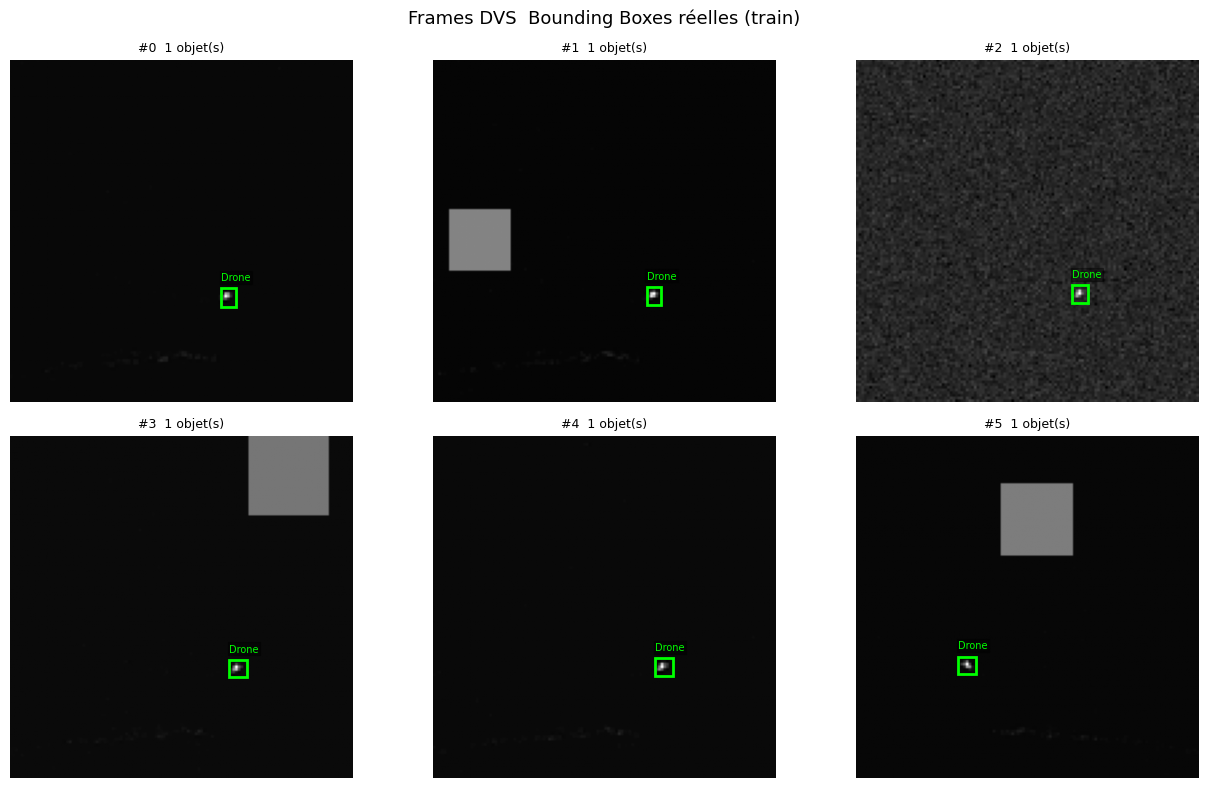

In [4]:
def show_samples_with_boxes(dataset, n=6, title="Exemples"):
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    fig.suptitle(title, fontsize=13)
    for i, ax in enumerate(axes.flatten()):
        if i >= n:
            ax.axis("off")
            continue
        image, target, boxes = dataset[i]
        img_np = np.clip(image.squeeze().numpy() * 0.5 + 0.5, 0, 1)
        ax.imshow(img_np, cmap="gray")
        for item in boxes:
            cls, xc, yc, w, h = item
            x1 = (xc - w/2) * IMG_SIZE
            y1 = (yc - h/2) * IMG_SIZE
            rect = patches.Rectangle(
                (x1, y1), w*IMG_SIZE, h*IMG_SIZE,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1-3, "Fond" if cls==1 else "Drone",
                    color="lime", fontsize=7,
                    bbox=dict(facecolor="black", alpha=0.4, pad=1))
        ax.set_title(f"#{i}  {len(boxes)} objet(s)", fontsize=9)
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_samples_with_boxes(train_dataset, title="Frames DVS  Bounding Boxes réelles (train)")


In [6]:
# Architecture SNN-YOLO v1+ (Backbone amélioré)
# Améliorations vs v1 classique :
# - 6 blocs ConvLIF au lieu de 5 (+1 bloc 512512 sans pooling)
# - Canaux doublés : 13264128256512 au lieu de 1163264128256
# - Dropout 0.3 avant la tête de détection (régularisation)
# - ~3.2M paramètres (vs ~400K avant)  bien dans la limite Kaggle GPU
# `
# Input : (B, 1, 128, 128)
# b1 : 132,   12864   (MaxPool)
# b2 : 3264,   6432   (MaxPool)
# b3 : 64128,  3216   (MaxPool)
# b4 : 128256, 168    (MaxPool)
# b5 : 256512,  84    (MaxPool)
# b6 : 512512,  44    (sans MaxPool  préserve la résolution)
# Tête : Dropout(0.3)  Upsample 47  Conv11(512256)  Conv11(2565)
# Sortie : (B, 7, 7, 5)
# `

In [7]:
import snntorch as snn
from snntorch import surrogate
import torch.nn as nn
import torch
import torch.nn.functional as F
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

BETA       = 0.9
NUM_STEPS  = 16
spike_grad = surrogate.fast_sigmoid(slope=25)


class ConvLIF(nn.Module):
    """Bloc Conv + BN + (optionnel MaxPool) + LIF."""
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()
        self.lif  = snn.Leaky(beta=BETA, spike_grad=spike_grad,
                               init_hidden=False)

    def forward(self, x, mem):
        cur      = self.pool(self.bn(self.conv(x)))
        spk, mem = self.lif(cur, mem)
        return spk, mem

    def init_mem(self):
        return self.lif.init_leaky()


class SNNYOLOv1Plus(nn.Module):
    """
    SNN-YOLO v1+ : backbone 6 blocs ConvLIF, canaux doublés, dropout.

    b1 : 132,   12864   (MaxPool)
    b2 : 3264,   6432   (MaxPool)
    b3 : 64128,  3216   (MaxPool)
    b4 : 128256, 168    (MaxPool)
    b5 : 256512,  84    (MaxPool)
    b6 : 512512,  44    (sans MaxPool  préserve résolution)
    Tête : Dropout  Upsample(77)  Conv11(512256)  Conv11(2565)
    """
    def __init__(self, grid_size=GRID_SIZE):
        super().__init__()
        self.grid_size = grid_size

        self.b1 = ConvLIF(1,   32,  pool=True)   # 12864
        self.b2 = ConvLIF(32,  64,  pool=True)   # 6432
        self.b3 = ConvLIF(64,  128, pool=True)   # 3216
        self.b4 = ConvLIF(128, 256, pool=True)   # 168
        self.b5 = ConvLIF(256, 512, pool=True)   # 84
        self.b6 = ConvLIF(512, 512, pool=False)  # 44  (sans pooling)

        self.dropout  = nn.Dropout2d(p=0.3)
        self.upsample = nn.Upsample(
            size=(grid_size, grid_size), mode='bilinear', align_corners=False)
        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 5, 1),   # [conf, x_off, y_off, w, h]
        )

    def forward(self, x):
        m1 = self.b1.init_mem()
        m2 = self.b2.init_mem()
        m3 = self.b3.init_mem()
        m4 = self.b4.init_mem()
        m5 = self.b5.init_mem()
        m6 = self.b6.init_mem()

        acc = torch.zeros(
            x.shape[0], 512,
            self.grid_size, self.grid_size,
            device=x.device
        )

        for _ in range(NUM_STEPS):
            s, m1 = self.b1(x,  m1)
            s, m2 = self.b2(s,  m2)
            s, m3 = self.b3(s,  m3)
            s, m4 = self.b4(s,  m4)
            s, m5 = self.b5(s,  m5)
            s, m6 = self.b6(s,  m6)
            acc  += self.upsample(s)

        feat = acc / NUM_STEPS          # rate coding : moyenne des spikes
        feat = self.dropout(feat)
        out  = self.head(feat)          # (B, 5, G, G)
        return out.permute(0, 2, 3, 1)  # (B, G, G, 5)


model = SNNYOLOv1Plus(grid_size=GRID_SIZE).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\n SNNYOLOv1+ prêt")
print(f"   Paramètres : {n_params:,}")
print(f"   Backbone   : 6 blocs ConvLIF (canaux doublés)")
print(f"   Dropout    : 0.3 avant la tête")
print(f"   NUM_STEPS  : {NUM_STEPS}  |  BETA : {BETA}")

# Test forward rapide
with torch.no_grad():
    dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    print(f"   Sortie     : {tuple(out.shape)}   attendu (2, 7, 7, 5)")


Device : cuda

 SNNYOLOv1+ prêt
   Paramètres : 4,063,941
   Backbone   : 6 blocs ConvLIF (canaux doublés)
   Dropout    : 0.3 avant la tête
   NUM_STEPS  : 16  |  BETA : 0.9
   Sortie     : (2, 7, 7, 5)   attendu (2, 7, 7, 5)


In [ ]:
# Loss YOLOv1+ : Focal BCE + LAMBDA_NOOBJ augmenté
# Clé pour éliminer les fausses alarmes :
# Focal Loss : FL(p) = -(1-p)^  log(p)
# Les cellules de fond avec une confiance déjà basse (p0) contribuent peu.
# Les cellules de fond avec une confiance élevée (p0.5) sont très pénalisées.
# Résultat : le modèle apprend à être très sûr avant de déclencher une détection.

In [8]:
LAMBDA_COORD = 5.0
LAMBDA_NOOBJ = 2.0    #  v1+ : 4 plus strict vs v1 classique (0.5)
FOCAL_GAMMA  = 2.0    #  exposant Focal Loss pour les fonds


def focal_bce_with_logits(logits, targets, gamma=FOCAL_GAMMA):
    """
    Focal Binary Cross-Entropy.
    FL(p) = -(1-p_t)^gamma * log(p_t)
    Pénalise fortement les cellules de fond avec une confiance élevée.
    """
    bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    prob = torch.sigmoid(logits)
    # p_t = prob si target=1, (1-prob) si target=0
    p_t  = targets * prob + (1 - targets) * (1 - prob)
    focal_weight = (1 - p_t) ** gamma
    return (focal_weight * bce).mean()


def yolo_loss_v1plus(predictions, targets, device):
    """
    Loss YOLOv1+ :
    - Focal BCE sur la confiance noobj  (anti fausses alarmes)
    - BCE standard sur la confiance obj (on veut 1.0 quand drone présent)
    - MSE sur x,y + MSE sur sqrt(w,h)  (coordonnées)
    predictions : (B, G, G, 5)   raw logits
    targets     : (B, G, G, 5)   [conf, x_off, y_off, w, h]
    """
    tgt = targets.to(device)

    obj_mask   = tgt[..., 0] == 1
    noobj_mask = tgt[..., 0] == 0

    z = torch.tensor(0.0, device=device)

    conf_pred = predictions[..., 0]

    # Cellules avec objet  BCE standard (on veut sigmoid  1)
    loss_obj = (F.binary_cross_entropy_with_logits(
        conf_pred[obj_mask], tgt[..., 0][obj_mask]
    ) if obj_mask.any() else z)

    # Cellules vides  Focal BCE (punit fort les faux positifs)
    loss_noobj = (focal_bce_with_logits(
        conf_pred[noobj_mask], tgt[..., 0][noobj_mask]
    ) if noobj_mask.any() else z)

    # Coordonnées (seulement cellules avec objet)
    if obj_mask.any():
        pred_xy = torch.sigmoid(predictions[..., 1:3][obj_mask])
        tgt_xy  = tgt[..., 1:3][obj_mask]
        loss_xy = F.mse_loss(pred_xy, tgt_xy)

        pred_wh = torch.clamp(torch.sigmoid(predictions[..., 3:5][obj_mask]), min=1e-6)
        tgt_wh  = torch.clamp(tgt[..., 3:5][obj_mask], min=1e-6)
        loss_wh = F.mse_loss(torch.sqrt(pred_wh), torch.sqrt(tgt_wh))

        loss_coord = loss_xy + loss_wh
    else:
        loss_coord = z

    total = (LAMBDA_COORD * loss_coord
             + loss_obj
             + LAMBDA_NOOBJ * loss_noobj)

    return total, loss_coord.item(), loss_obj.item(), loss_noobj.item()


# Test
dummy_pred = torch.randn(4, GRID_SIZE, GRID_SIZE, 5).to(device)
dummy_tgt  = torch.zeros(4, GRID_SIZE, GRID_SIZE, 5)
dummy_tgt[0, 3, 3] = torch.tensor([1.0, 0.5, 0.5, 0.1, 0.1])
total, lc, lo, lno = yolo_loss_v1plus(dummy_pred, dummy_tgt, device)
print(f" Loss v1+ OK")
print(f"   total={total:.4f}  coord={lc:.4f}  obj={lo:.4f}  noobj(focal)={lno:.4f}")
print(f"   LAMBDA_NOOBJ={LAMBDA_NOOBJ}  FOCAL_GAMMA={FOCAL_GAMMA}")


 Loss v1+ OK
   total=3.1488  coord=0.2535  obj=1.0253  noobj(focal)=0.4280
   LAMBDA_NOOBJ=2.0  FOCAL_GAMMA=2.0


In [ ]:
# Entraînement (60 epochs, warmup + cosine decay)

In [9]:
NUM_EPOCHS    = 60
WARMUP_EPOCHS = 6
LR_MAX        = 5e-4   # légèrement réduit pour le modèle plus large
LR_MIN        = 1e-5

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR_MAX, weight_decay=2e-4)


def get_lr_factor(epoch):
    if epoch < WARMUP_EPOCHS:
        return LR_MIN/LR_MAX + (1.0 - LR_MIN/LR_MAX) * epoch / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(NUM_EPOCHS - WARMUP_EPOCHS - 1, 1)
    cosine = 0.5 * (1 + math.cos(math.pi * t))
    return LR_MIN/LR_MAX + (1.0 - LR_MIN/LR_MAX) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=get_lr_factor)

hist = {"total": [], "coord": [], "obj": [], "noobj": [], "val": []}
best_val_loss = float("inf")
patience      = 0
PATIENCE_MAX  = 15

print(f" Entraînement SNN-YOLO v1+  {NUM_EPOCHS} epochs")
print(f"   LR max={LR_MAX}  warmup={WARMUP_EPOCHS}ep  weight_decay=2e-4")
print(f"   LAMBDA_NOOBJ={LAMBDA_NOOBJ}  FOCAL_GAMMA={FOCAL_GAMMA}\n")

for epoch in range(NUM_EPOCHS):
    #  Train 
    model.train()
    ep_total = ep_coord = ep_obj = ep_noobj = 0.0
    n = 0

    for images, targets, _ in train_loader:
        images = images.to(device)
        preds  = model(images)
        loss, lc, lo, lno = yolo_loss_v1plus(preds, targets, device)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        ep_total += loss.item()
        ep_coord += lc
        ep_obj   += lo
        ep_noobj += lno
        n += 1

    scheduler.step()

    #  Validation 
    model.eval()
    val_loss = 0.0
    nv = 0
    with torch.no_grad():
        for images, targets, _ in val_loader:
            images  = images.to(device)
            preds   = model(images)
            loss_v, _, _, _ = yolo_loss_v1plus(preds, targets, device)
            val_loss += loss_v.item()
            nv += 1
    val_loss /= max(nv, 1)

    hist["total"].append(ep_total / n)
    hist["coord"].append(ep_coord / n)
    hist["obj"].append(ep_obj / n)
    hist["noobj"].append(ep_noobj / n)
    hist["val"].append(val_loss)

    lr_now = optimizer.param_groups[0]['lr']
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Ep {epoch+1:3d}/{NUM_EPOCHS}  "
              f"train={ep_total/n:.4f}  val={val_loss:.4f}  "
              f"coord={ep_coord/n:.4f}  obj={ep_obj/n:.4f}  "
              f"noobj={ep_noobj/n:.4f}  lr={lr_now:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience = 0
        torch.save(model.state_dict(),
                   "/kaggle/working/best_snnyolo_v1plus.pth")
    else:
        patience += 1
        if patience >= PATIENCE_MAX:
            print(f"\n Early stopping à l'epoch {epoch+1}")
            break

print(f"\n Entraînement terminé. Best val loss : {best_val_loss:.4f}")
print("   Chargement du meilleur modèle...")
model.load_state_dict(
    torch.load("/kaggle/working/best_snnyolo_v1plus.pth",
               map_location=device))
print("    Meilleur checkpoint chargé.")


 Entraînement SNN-YOLO v1+  60 epochs
   LR max=0.0005  warmup=6ep  weight_decay=2e-4
   LAMBDA_NOOBJ=2.0  FOCAL_GAMMA=2.0

Ep   1/60  train=2.0893  val=1.7959  coord=0.2235  obj=0.4837  noobj=0.2440  lr=9.17e-05
Ep   5/60  train=1.0314  val=1.2544  coord=0.0812  obj=0.3955  noobj=0.1150  lr=4.18e-04
Ep  10/60  train=0.5128  val=0.4195  coord=0.0347  obj=0.2109  noobj=0.0643  lr=4.93e-04
Ep  15/60  train=0.3330  val=0.3432  coord=0.0211  obj=0.1407  noobj=0.0435  lr=4.66e-04
Ep  20/60  train=0.3110  val=0.3015  coord=0.0179  obj=0.1413  noobj=0.0402  lr=4.20e-04
Ep  25/60  train=0.2678  val=0.2540  coord=0.0159  obj=0.1181  noobj=0.0350  lr=3.60e-04
Ep  30/60  train=0.2599  val=0.2388  coord=0.0158  obj=0.1136  noobj=0.0336  lr=2.91e-04
Ep  35/60  train=0.2322  val=0.2227  coord=0.0142  obj=0.1008  noobj=0.0302  lr=2.19e-04
Ep  40/60  train=0.2236  val=0.1917  coord=0.0130  obj=0.1014  noobj=0.0286  lr=1.50e-04
Ep  45/60  train=0.1952  val=0.1781  coord=0.0109  obj=0.0864  noobj=0.0270

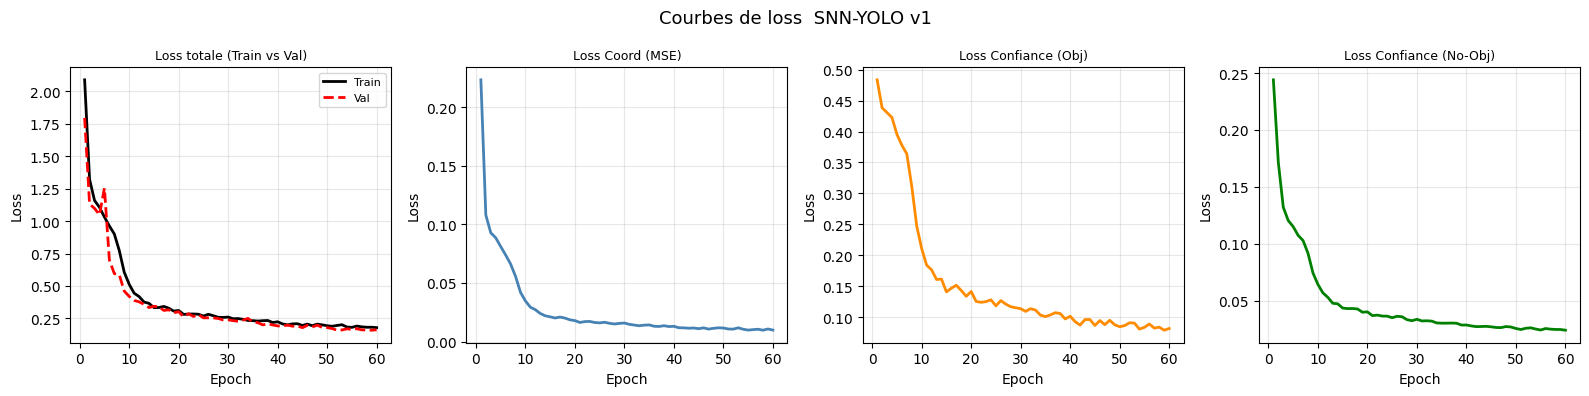

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [
    ("total",  "Loss totale (Train vs Val)", "black"),
    ("coord",  "Loss Coord (MSE)",           "steelblue"),
    ("obj",    "Loss Confiance (Obj)",        "darkorange"),
    ("noobj",  "Loss Confiance (No-Obj)",     "green"),
]
for ax, (key, title, color) in zip(axes, configs):
    epochs_range = range(1, len(hist[key]) + 1)
    ax.plot(epochs_range, hist[key], color=color, linewidth=2, label="Train")
    if key == "total":
        ax.plot(epochs_range, hist["val"],
                color="red", linewidth=2, linestyle="--", label="Val")
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.suptitle("Courbes de loss  SNN-YOLO v1", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Décodage des prédictions + NMS
# - Décodage YOLOv1 : sigmoid sur conf, x_off, y_off, w, h
# - Seuillage : on ne garde que les cellules avec conf > threshold
# - NMS : pour les cas rares où 2 cellules adjacentes détectent le même drone
# - Résultat : au maximum 1 boîte par drone (souvent exactement 1)

In [11]:
import numpy as np

CONF_THRESH = 0.5   #  v1+ : seuil plus élevé  moins de fausses alarmes
IOU_THRESH  = 0.5


def nms(boxes, iou_threshold=0.5):
    """Non-Maximum Suppression. boxes : [[x1,y1,x2,y2,conf], ...]"""
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        remaining = []
        for b in boxes:
            ix1 = max(best[0], b[0]); iy1 = max(best[1], b[1])
            ix2 = min(best[2], b[2]); iy2 = min(best[3], b[3])
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            a1 = (best[2]-best[0]) * (best[3]-best[1])
            a2 = (b[2]-b[0])       * (b[3]-b[1])
            iou = inter / (a1 + a2 - inter + 1e-6)
            if iou < iou_threshold:
                remaining.append(b)
        boxes = remaining
    return kept


def decode_predictions(preds, grid_size, conf_thresh=CONF_THRESH):
    """
    Décode (B, G, G, 5)  1 seule boîte par image (celle avec le score max).
    Retourne : list[list]  soit [] soit [[x1, y1, x2, y2, conf]]
    """
    B, G, _, _ = preds.shape
    all_boxes = []

    for b in range(B):
        candidates = []

        for gy in range(G):
            for gx in range(G):
                raw  = preds[b, gy, gx]
                conf = torch.sigmoid(raw[0]).item()

                if conf < conf_thresh:
                    continue

                x_off = torch.sigmoid(raw[1]).item()
                y_off = torch.sigmoid(raw[2]).item()
                w     = torch.sigmoid(raw[3]).item()
                h     = torch.sigmoid(raw[4]).item()

                xc = (gx + x_off) / grid_size
                yc = (gy + y_off) / grid_size

                x1 = max(0.0, xc - w/2)
                y1 = max(0.0, yc - h/2)
                x2 = min(1.0, xc + w/2)
                y2 = min(1.0, yc + h/2)

                if x2 > x1 and y2 > y1:
                    candidates.append([x1, y1, x2, y2, conf])

        # Garder UNIQUEMENT la boîte avec le score de confiance le plus élevé
        if candidates:
            best_box = max(candidates, key=lambda x: x[4])
            all_boxes.append([best_box])
        else:
            all_boxes.append([])  # aucune détection

    return all_boxes


def decode_predictions_all(preds, grid_size):
    """
    Version sans filtre pour le calcul de mAP (courbe P-R complète).
    Retourne toutes les cellules avec leur score, triées par confiance décroissante.
    """
    B, G, _, _ = preds.shape
    all_boxes = []

    for b in range(B):
        candidates = []
        for gy in range(G):
            for gx in range(G):
                raw  = preds[b, gy, gx]
                conf = torch.sigmoid(raw[0]).item()
                x_off = torch.sigmoid(raw[1]).item()
                y_off = torch.sigmoid(raw[2]).item()
                w     = torch.sigmoid(raw[3]).item()
                h     = torch.sigmoid(raw[4]).item()
                xc = (gx + x_off) / grid_size
                yc = (gy + y_off) / grid_size
                x1 = max(0.0, xc - w/2)
                y1 = max(0.0, yc - h/2)
                x2 = min(1.0, xc + w/2)
                y2 = min(1.0, yc + h/2)
                if x2 > x1 and y2 > y1:
                    candidates.append([x1, y1, x2, y2, conf])
        # Pour mAP : garder quand même seulement le meilleur candidat par image
        if candidates:
            all_boxes.append([max(candidates, key=lambda x: x[4])])
        else:
            all_boxes.append([])

    return all_boxes


def iou_box(b1, b2):
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0.0, ix2-ix1) * max(0.0, iy2-iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)


print(" Décodage : 1 seule boîte par image (score max).")
print(f"   Seuil conf minimum : {CONF_THRESH}")


 Décodage : 1 seule boîte par image (score max).
   Seuil conf minimum : 0.5


Évaluation en cours...


  Évaluation  Train
  Seuil conf : 0.5  |  IoU@0.5
  TP=1305  FP=1079  FN=597
  Précision  @IoU0.5 : 0.5474
  Rappel     @IoU0.5 : 0.6861
  F1-score           : 0.6090
  IoU moyen (TP)     : 0.6557
  
  mAP@0.5            : 0.5684   métrique principale

  Évaluation  Validation
  Seuil conf : 0.5  |  IoU@0.5
  TP=520  FP=416  FN=208
  Précision  @IoU0.5 : 0.5556
  Rappel     @IoU0.5 : 0.7143
  F1-score           : 0.6250
  IoU moyen (TP)     : 0.6586
  
  mAP@0.5            : 0.6002   métrique principale

  Résumé Train vs Validation
  Précision  @IoU0.5      Train:0.5474  Val:0.5556
  Rappel     @IoU0.5      Train:0.6861  Val:0.7143
  F1-score                Train:0.6090  Val:0.6250
  IoU moyen (TP)          Train:0.6557  Val:0.6586
  mAP@0.5                 Train:0.5684  Val:0.6002


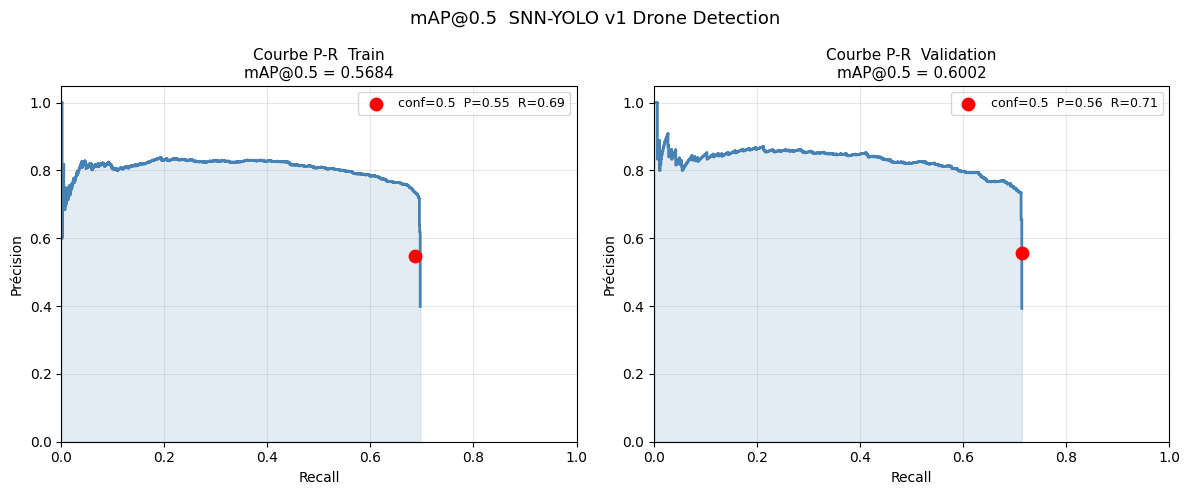

In [12]:
def compute_map(model, loader, grid_size, device, iou_thresh=0.5):
    """mAP@0.5 interpolation 101 points (VOC 2010+)."""
    model.eval()
    all_detections = []
    total_gt       = 0

    with torch.no_grad():
        for images, targets, gt_boxes_batch in loader:
            images = images.to(device)
            preds  = model(images)
            pred_boxes_batch = decode_predictions_all(preds, grid_size)

            for pred_boxes, gt_boxes in zip(pred_boxes_batch, gt_boxes_batch):
                gt_decoded = [
                    [xc-w/2, yc-h/2, xc+w/2, yc+h/2]
                    for _, xc, yc, w, h in gt_boxes
                ]
                total_gt += len(gt_decoded)

                matched_gt = set()
                for pb in pred_boxes:
                    best_iou, best_j = 0.0, -1
                    for j, gb in enumerate(gt_decoded):
                        iou = iou_box(pb[:4], gb)
                        if iou > best_iou:
                            best_iou, best_j = iou, j
                    is_tp = (best_iou >= iou_thresh and best_j not in matched_gt)
                    if is_tp:
                        matched_gt.add(best_j)
                    all_detections.append((pb[4], int(is_tp)))

    if not all_detections or total_gt == 0:
        return 0.0, np.array([]), np.array([])

    all_detections.sort(key=lambda x: x[0], reverse=True)
    tps  = np.array([d[1] for d in all_detections])
    cum_tp = np.cumsum(tps)
    cum_fp = np.cumsum(1 - tps)
    precisions = cum_tp / (cum_tp + cum_fp + 1e-6)
    recalls    = cum_tp / (total_gt + 1e-6)

    recall_interp    = np.linspace(0, 1, 101)
    precision_interp = np.zeros(101)
    for i, r in enumerate(recall_interp):
        mask = recalls >= r
        precision_interp[i] = precisions[mask].max() if mask.any() else 0.0

    return float(np.mean(precision_interp)), recalls, precisions


def evaluate_full(model, loader, grid_size, device, split=""):
    model.eval()
    all_ious = []
    tp = fp = fn = 0

    with torch.no_grad():
        for images, targets, gt_boxes_batch in loader:
            images = images.to(device)
            preds  = model(images)
            pred_boxes_batch = decode_predictions(preds, grid_size, CONF_THRESH)

            for pred_boxes, gt_boxes in zip(pred_boxes_batch, gt_boxes_batch):
                gt_decoded = [
                    [xc-w/2, yc-h/2, xc+w/2, yc+h/2]
                    for _, xc, yc, w, h in gt_boxes
                ]
                matched_gt = set()

                for pb in pred_boxes:
                    best_iou, best_j = 0.0, -1
                    for j, gb in enumerate(gt_decoded):
                        iou = iou_box(pb[:4], gb)
                        if iou > best_iou:
                            best_iou, best_j = iou, j
                    if best_iou >= IOU_THRESH and best_j not in matched_gt:
                        tp += 1
                        matched_gt.add(best_j)
                        all_ious.append(best_iou)
                    else:
                        fp += 1

                fn += len(gt_decoded) - len(matched_gt)

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    mean_iou  = float(np.mean(all_ious)) if all_ious else 0.0

    ap, rc_curve, pc_curve = compute_map(model, loader, grid_size, device)

    print(f"\n{'='*58}")
    print(f"  Évaluation  {split}")
    print(f"{'='*58}")
    print(f"  Seuil conf : {CONF_THRESH}  |  IoU@0.5")
    print(f"  TP={tp}  FP={fp}  FN={fn}")
    print(f"  Précision  @IoU0.5 : {precision:.4f}")
    print(f"  Rappel     @IoU0.5 : {recall:.4f}")
    print(f"  F1-score           : {f1:.4f}")
    print(f"  IoU moyen (TP)     : {mean_iou:.4f}")
    print(f"  {''*48}")
    print(f"  mAP@0.5            : {ap:.4f}   métrique principale")

    return precision, recall, f1, mean_iou, ap, rc_curve, pc_curve


print("Évaluation en cours...\n")

p_tr,  r_tr,  f1_tr,  iou_tr,  map_tr,  rc_tr,  pc_tr  = evaluate_full(
    model, train_loader, GRID_SIZE, device, "Train")

p_val, r_val, f1_val, iou_val, map_val, rc_val, pc_val = evaluate_full(
    model, val_loader,   GRID_SIZE, device, "Validation")

print(f"\n{'='*58}")
print(f"  Résumé Train vs Validation")
print(f"{'='*58}")
for label, tr, va in [
    ("Précision  @IoU0.5", p_tr,   p_val),
    ("Rappel     @IoU0.5", r_tr,   r_val),
    ("F1-score",           f1_tr,  f1_val),
    ("IoU moyen (TP)",     iou_tr, iou_val),
    ("mAP@0.5  ",         map_tr, map_val),
]:
    print(f"  {label:22s}  Train:{tr:.4f}  Val:{va:.4f}")

#  Courbes P-R 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (rc, pc, ap, pfix, rfix, title) in zip(axes, [
    (rc_tr,  pc_tr,  map_tr,  p_tr,  r_tr,  "Train"),
    (rc_val, pc_val, map_val, p_val, r_val, "Validation"),
]):
    if len(rc) > 0:
        ax.step(rc, pc, color="steelblue", linewidth=2, where="post")
        ax.fill_between(rc, pc, alpha=0.15, color="steelblue", step="post")
    ax.scatter([rfix], [pfix], color="red", zorder=5, s=80,
               label=f"conf={CONF_THRESH}  P={pfix:.2f}  R={rfix:.2f}")
    ax.set_title(f"Courbe P-R  {title}\nmAP@0.5 = {ap:.4f}", fontsize=11)
    ax.set_xlabel("Recall"); ax.set_ylabel("Précision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("mAP@0.5  SNN-YOLO v1 Drone Detection", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Visualisation : Ground Truth vs Prédictions
# 1 seule boîte rouge par image = la cellule avec la confiance la plus haute.
# -  Vert = Ground Truth (vérité terrain)
# -  Rouge (tirets) = Prédiction du modèle + score de confiance
# - Le score affiché = sigmoid(logit_confiance) de la meilleure cellule
# On affiche 24 exemples (4 colonnes  6 lignes) pour avoir une vue d'ensemble.

=== VALIDATION  24 exemples ===


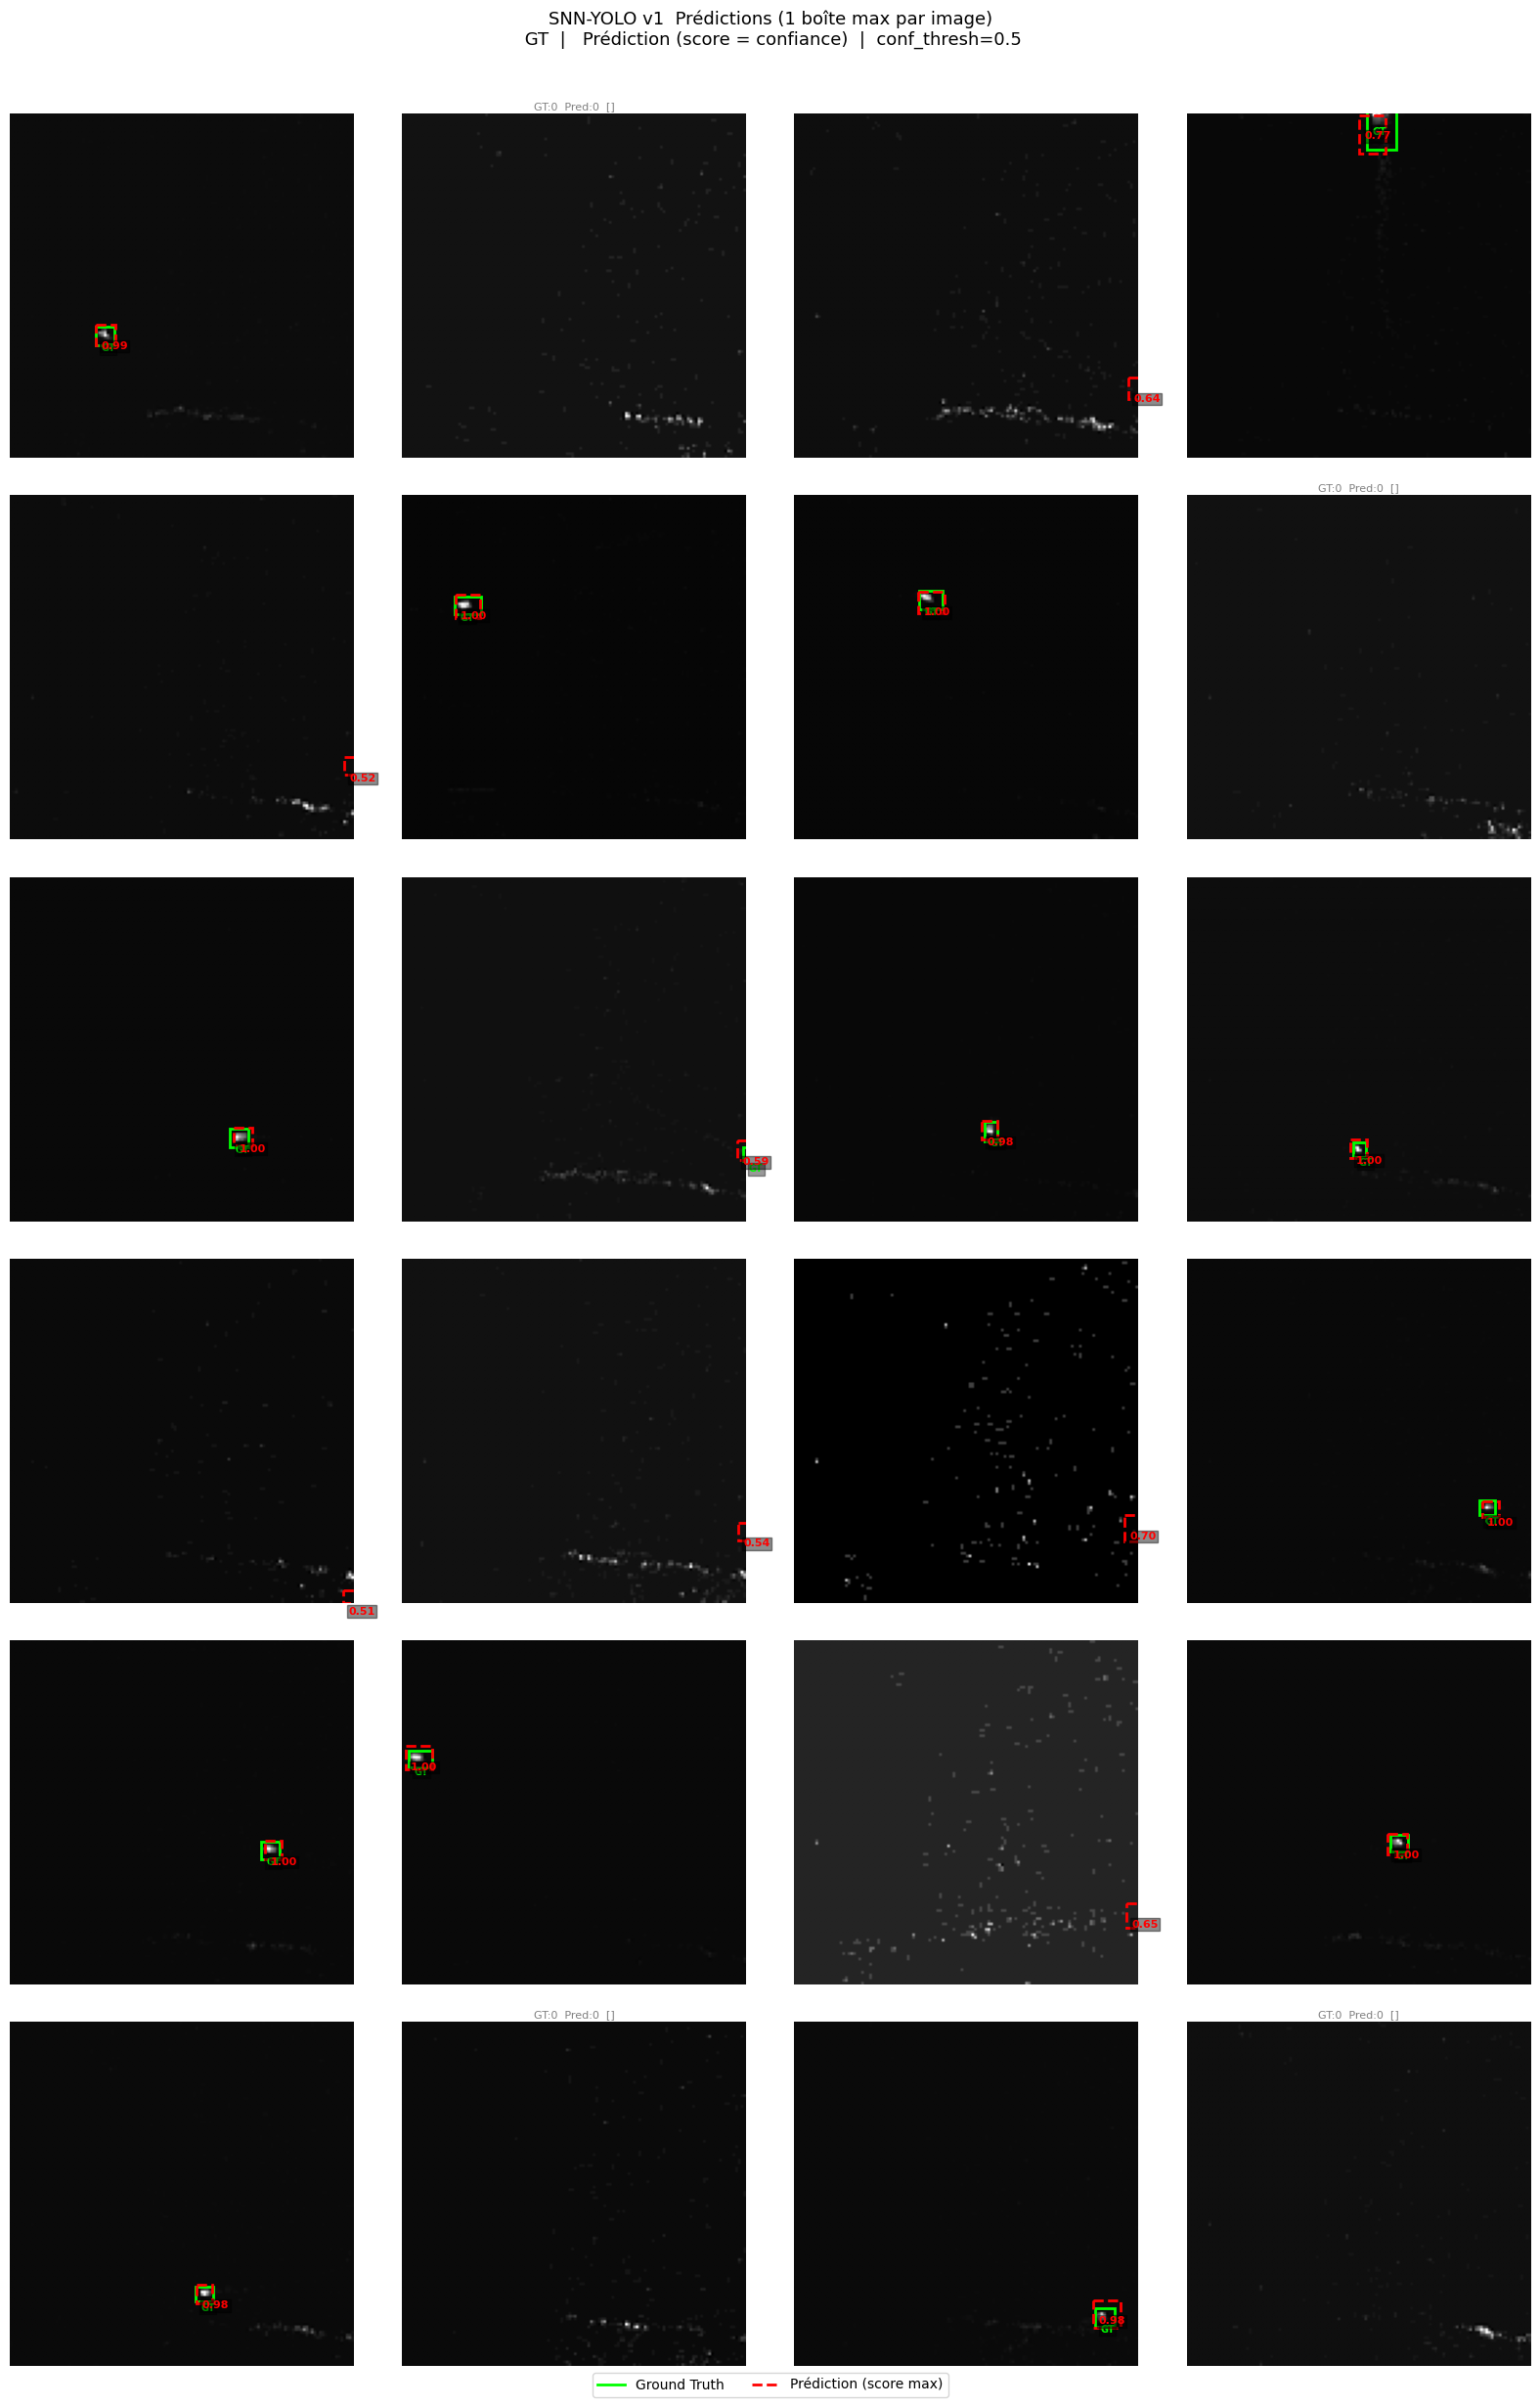


 Figure sauvegardée dans /kaggle/working/visualisation_predictions.png
   Légende titre : GT=nb objets réels | Pred=nb prédictions
   []=correct  [FP]=fausse alarme  [FN]=drone manqué  []=fond correct

=== TRAIN  24 exemples ===


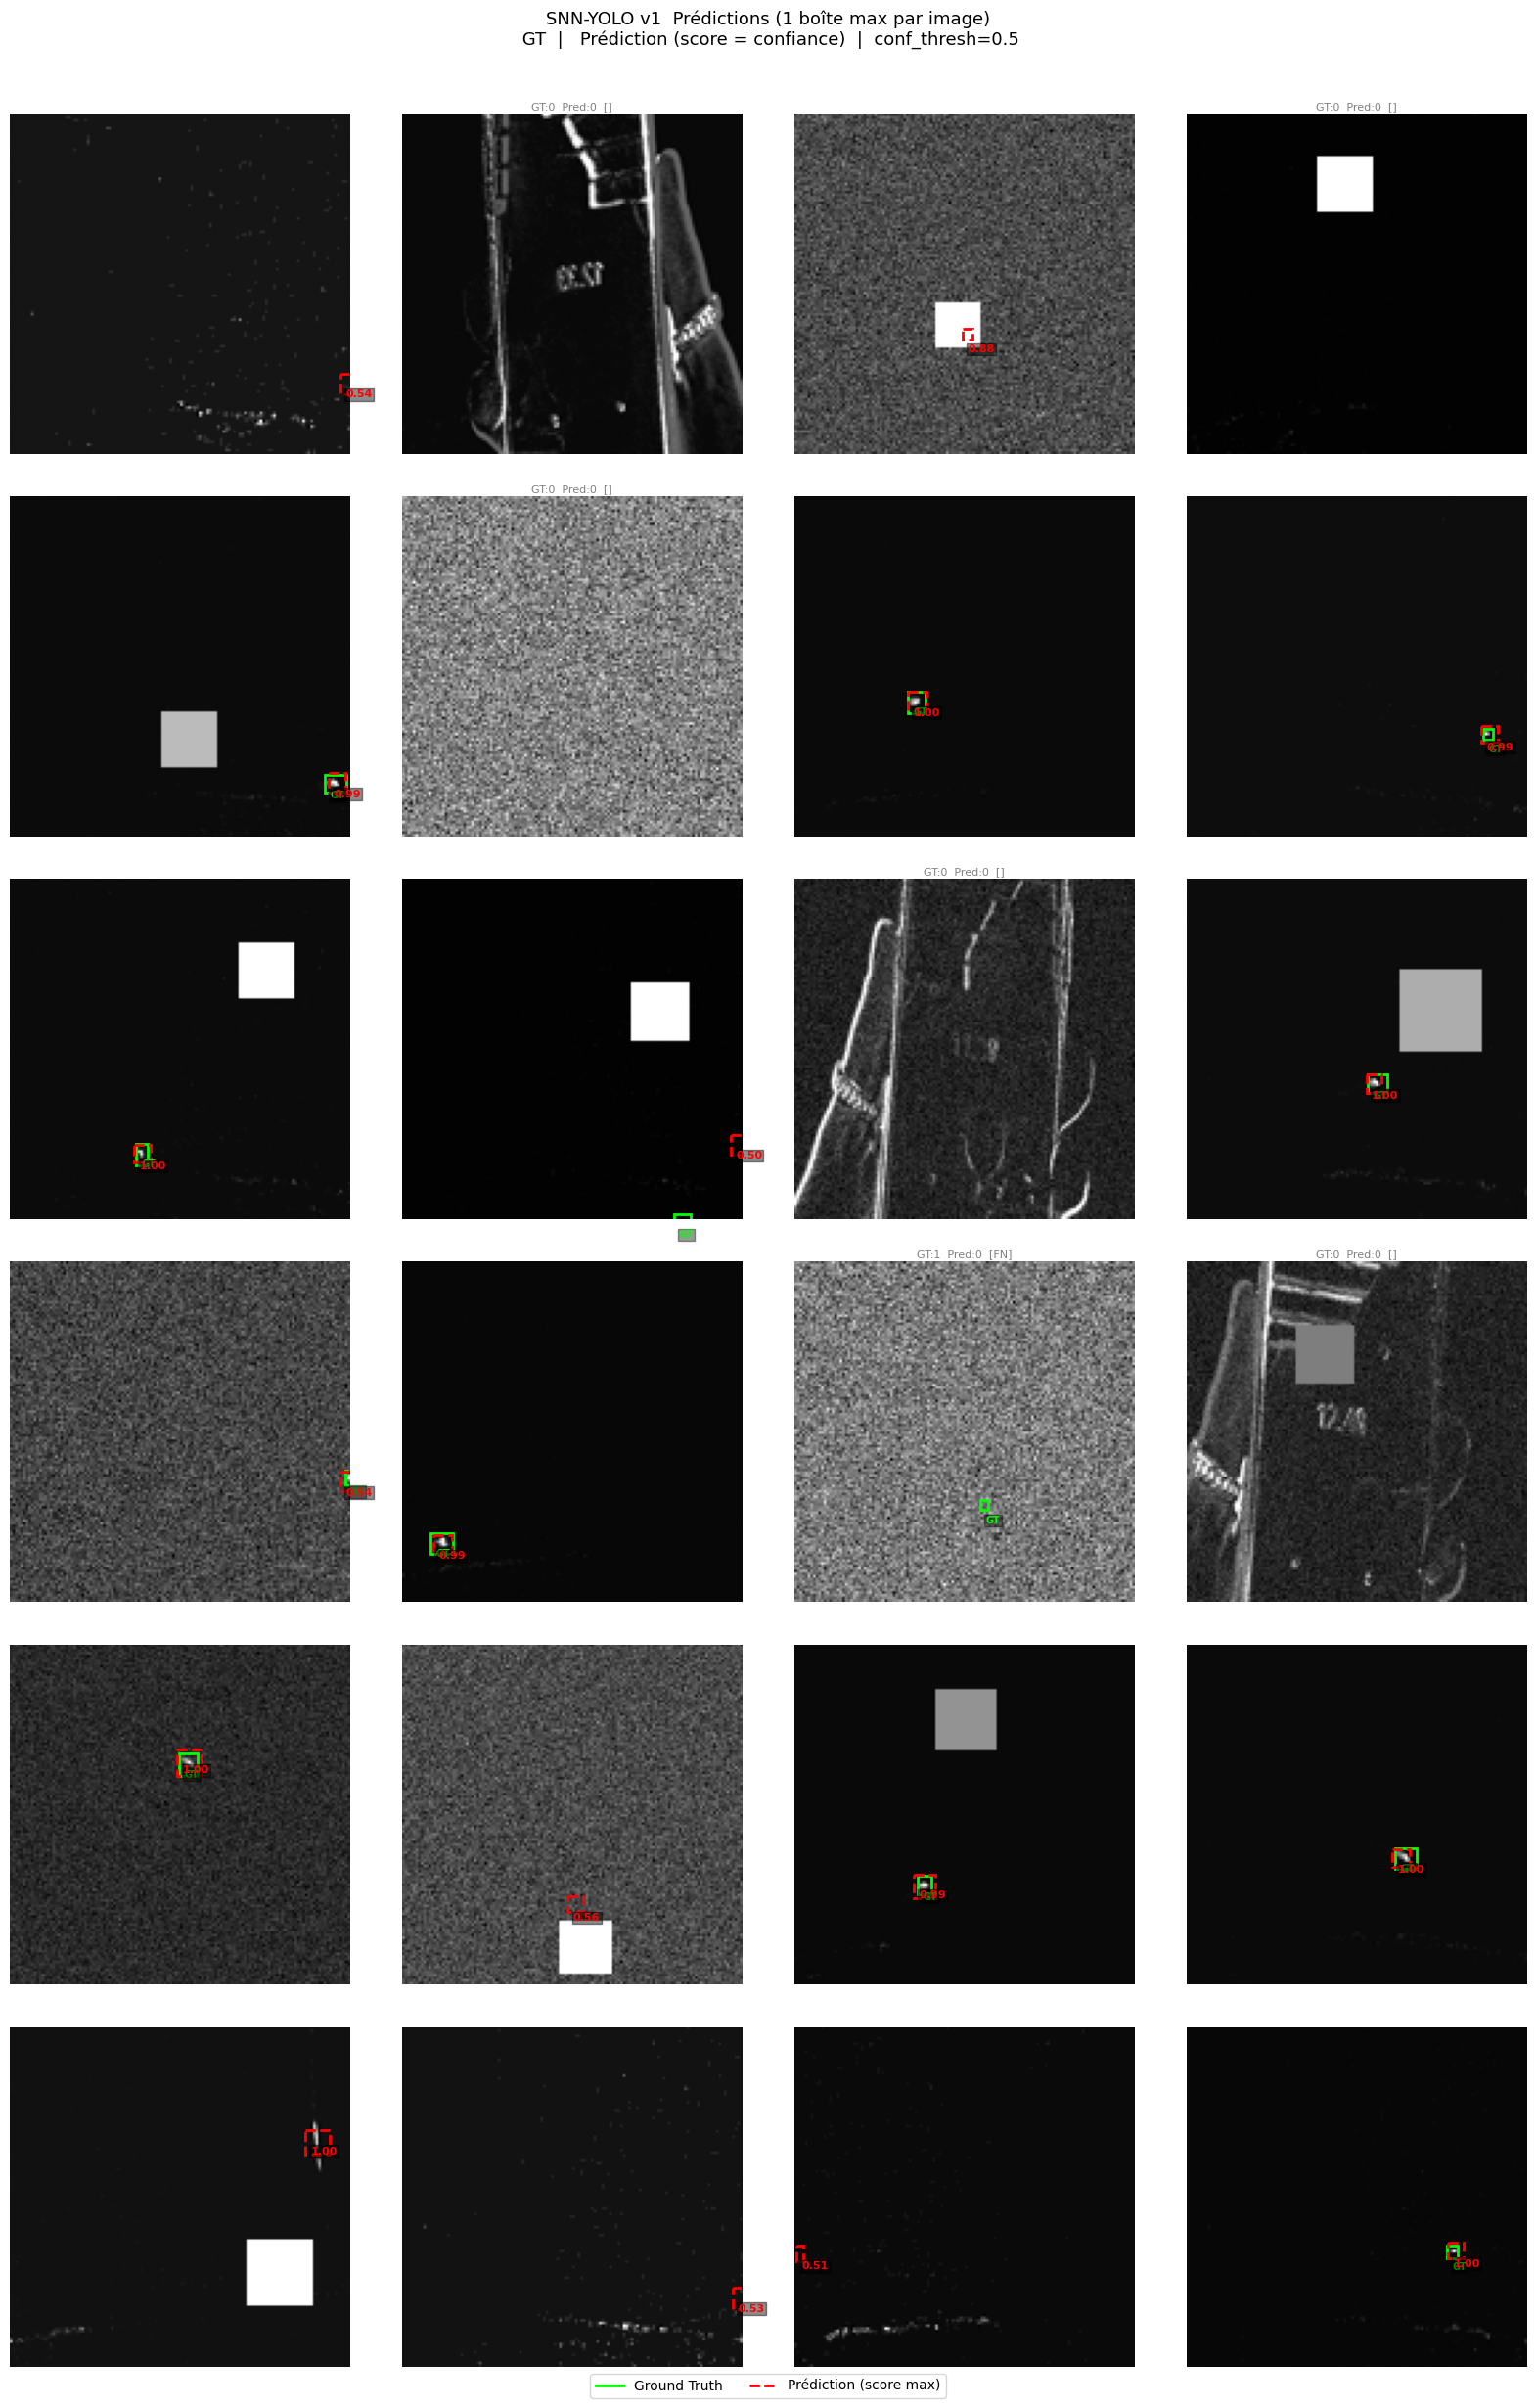


 Figure sauvegardée dans /kaggle/working/visualisation_predictions.png
   Légende titre : GT=nb objets réels | Pred=nb prédictions
   []=correct  [FP]=fausse alarme  [FN]=drone manqué  []=fond correct


In [13]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D


def visualize_predictions(model, dataset, grid_size, device,
                           conf_thresh=CONF_THRESH, n_examples=24):
    """
    Affiche n_examples images en grille.
    Chaque image : GT (vert) + prédiction max-score (rouge tirets).
    Layout : n_examples // 4 lignes  4 colonnes.
    """
    model.eval()
    n_cols = 4
    n_rows = n_examples // n_cols
    indices = np.random.choice(len(dataset), min(n_examples, len(dataset)), replace=False)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 4))
    fig.suptitle(
        f"SNN-YOLO v1  Prédictions (1 boîte max par image)\n"
        f" GT  |   Prédiction (score = confiance)  |  conf_thresh={conf_thresh}",
        fontsize=13, y=1.01
    )

    with torch.no_grad():
        for i, idx in enumerate(indices):
            row = i // n_cols
            col = i %  n_cols
            ax  = axes[row][col]

            image, target, gt_boxes = dataset[idx]
            pred   = model(image.unsqueeze(0).to(device))
            pred_b = decode_predictions(pred, grid_size, conf_thresh)[0]

            img_np = np.clip(image.squeeze().numpy() * 0.5 + 0.5, 0, 1)
            ax.imshow(img_np, cmap="gray")

            #  Ground Truth  vert 
            for item in gt_boxes:
                cls, xc, yc, w, h = item
                x1 = (xc - w/2) * IMG_SIZE
                y1 = (yc - h/2) * IMG_SIZE
                ax.add_patch(patches.Rectangle(
                    (x1, y1), w*IMG_SIZE, h*IMG_SIZE,
                    linewidth=2, edgecolor="lime", facecolor="none"
                ))
                ax.text(x1 + 2, y1 + 9, "GT",
                        color="lime", fontsize=7, fontweight="bold",
                        bbox=dict(facecolor="black", alpha=0.4, pad=1))

            #  Prédiction (score max)  rouge tirets 
            if pred_b:
                pb = pred_b[0]  # toujours 1 seule boîte
                x1p = pb[0] * IMG_SIZE
                y1p = pb[1] * IMG_SIZE
                ww  = (pb[2] - pb[0]) * IMG_SIZE
                hh  = (pb[3] - pb[1]) * IMG_SIZE
                ax.add_patch(patches.Rectangle(
                    (x1p, y1p), ww, hh,
                    linewidth=2, edgecolor="red",
                    facecolor="none", linestyle="--"
                ))
                ax.text(x1p + 2, y1p + 9,
                        f"{pb[4]:.2f}",
                        color="red", fontsize=8, fontweight="bold",
                        bbox=dict(facecolor="black", alpha=0.45, pad=1))
                title_color = "white"
                status = "" if gt_boxes else "FP"
            else:
                title_color = "gray"
                status = "" if not gt_boxes else "FN"

            n_gt = len(gt_boxes)
            ax.set_title(f"GT:{n_gt}  Pred:{len(pred_b)}  [{status}]",
                         fontsize=8, color=title_color,
                         pad=3)
            ax.axis("off")

    # Légende globale
    legend_elements = [
        Line2D([0],[0], color="lime", lw=2, label="Ground Truth"),
        Line2D([0],[0], color="red",  lw=2, ls="--", label="Prédiction (score max)"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout()
    plt.savefig("/kaggle/working/visualisation_predictions.png",
                dpi=100, bbox_inches="tight")
    plt.show()
    print(f"\n Figure sauvegardée dans /kaggle/working/visualisation_predictions.png")
    print(f"   Légende titre : GT=nb objets réels | Pred=nb prédictions")
    print(f"   []=correct  [FP]=fausse alarme  [FN]=drone manqué  []=fond correct")


#  Train : 24 exemples 
print("=== VALIDATION  24 exemples ===")
visualize_predictions(
    model, val_dataset, GRID_SIZE, device,
    conf_thresh=CONF_THRESH, n_examples=24
)

#  Exemples avec GT seulement (sans drone) pour voir les FP 
print("\n=== TRAIN  24 exemples ===")
visualize_predictions(
    model, train_dataset, GRID_SIZE, device,
    conf_thresh=CONF_THRESH, n_examples=24
)


In [16]:
import os

SAVE_PATH = "/kaggle/working/snnyolo_v1plus_drone_detector.pth"
torch.save({
    "model_state_dict"    : model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "hist"                : hist,
    "num_steps"           : NUM_STEPS,
    "img_size"            : IMG_SIZE,
    "grid_size"           : GRID_SIZE,
    "beta"                : BETA,
    "conf_thresh"         : CONF_THRESH,
    "iou_thresh"          : IOU_THRESH,
    "lambda_noobj"        : LAMBDA_NOOBJ,
    "focal_gamma"         : FOCAL_GAMMA,
    "version"             : "v1plus",
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f" Modèle SNN-YOLO v1+ sauvegardé : {SAVE_PATH}  ({size_mb:.2f} MB)")
print(f"   Paramètres   : {sum(p.numel() for p in model.parameters()):,}")
print(f"   Architecture : 6 blocs ConvLIF (canaux doublés) + Dropout")
print(f"   Loss         : Focal BCE noobj (={FOCAL_GAMMA})  LAMBDA_NOOBJ={LAMBDA_NOOBJ}")
print(f"   CONF_THRESH  : {CONF_THRESH}")


 Modèle SNN-YOLO v1+ sauvegardé : /kaggle/working/snnyolo_v1plus_drone_detector.pth  (48.84 MB)
   Paramètres   : 4,063,941
   Architecture : 6 blocs ConvLIF (canaux doublés) + Dropout
   Loss         : Focal BCE noobj (=2.0)  LAMBDA_NOOBJ=2.0
   CONF_THRESH  : 0.5
